In [1]:
import os
import json

import numpy as np

os.environ["JAX_PLATFORMS"] = "cpu"
import jax
import jax.numpy as jnp

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from matplotlib.lines import Line2D

from utils import load_pass_curves
from utils import threshold_to_profit_batch
from utils import cost_for_pass, get_arbitrage_prices

In [2]:
base_dir = "../data/swebench/"

results = {}
for file in os.listdir(base_dir):
    if not file.endswith(".jsonl"):
        continue

    model_name = file.split(".jsonl")[0]
    data = [json.loads(line) for line in open(os.path.join(base_dir, file), "r")]
    results[model_name] = data

## Figure 6 - Larger market

In [3]:
model_names = {
    'minicoder4b': 'mini-coder 4B',
    'qwen3-coder-30b': 'Qwen3 Coder 30B',
    'qwen3-coder-480b': 'Qwen3 Coder gpt5',
    'gpt5mini': 'GPT-5 mini',
    'deepseek': 'DeepSeek',
    'sonnet': 'Claude Sonnet',
}
models = list(model_names.keys())

budget_grid = np.logspace(np.log10(1e-4), np.log10(1), 250)
providers_perf = load_pass_curves(results, models, budget_grid)
performance_grid = jnp.linspace(0.4, providers_perf.mean(axis=0).max(), 100)

In [4]:
provider_prices = np.array([
    cost_for_pass(budget_grid, p, performance_grid)
    for p in providers_perf.mean(axis=0)
])
market_price = provider_prices.min(axis=0)

In [5]:
performance_grid_plot = jnp.linspace(0.0, providers_perf.mean(axis=0).max(), 100)

provider_prices_plot = np.array([
    cost_for_pass(budget_grid, p, performance_grid_plot)
    for p in providers_perf.mean(axis=0)
])
market_price_plot = provider_prices_plot.min(axis=0)

We have verified that Qwen Coder gpt5 and Sonnet do not recieve any revenue. Therefore, we do grid search over the remaining 4 models.

In [6]:
max_budget = 1
computes = np.r_[0, np.logspace(np.log10(1e-3), np.log10(max_budget), 20)]

X1, X2, X3, X4 = np.meshgrid(
    computes, computes, computes, computes,
    indexing="ij"
)

points = np.stack((X1, X2, X3, X4), axis=-1).reshape(-1, 4)

# filtering...
def enforce_row_sum(points, X):
    points = points.copy()
    
    row_sums = points.sum(axis=1)
    excess = np.maximum(row_sums - X, 0.0)  # only positive excess
    
    # Go from last column to first
    for j in reversed(range(points.shape[1])):
        reduction = np.minimum(points[:, j], excess)
        points[:, j] -= reduction
        excess -= reduction
    
    return points

points = enforce_row_sum(points, max_budget)
points = np.unique(np.round(points, decimals=8), axis=0)

def is_monotonic_ignore_zeros(arr):
    # 1. Create a copy to avoid modifying original data
    temp = arr.copy()
    
    # 2. Forward fill zeros with the previous element's value
    # This ensures zeros don't trigger a "decrease" or "increase" 
    # relative to the elements around them.
    for i in range(1, temp.shape[1]):
        mask = temp[:, i] == 0
        temp[mask, i] = temp[mask, i-1]

    # 3. Calculate differences on the filled array
    diffs = np.diff(temp, axis=1)
    
    # 4. Check for monotonicity (>= 0 allows the "filled" zeros to pass)
    # We also need to ensure the non-zero values actually increased.
    # A simple way is to check if the sequence is non-decreasing.
    return np.all(diffs >= 0, axis=1)

mask = is_monotonic_ignore_zeros(points)
points = points[mask]
prices_vmap = jax.vmap(get_arbitrage_prices, in_axes=(None, None, 0, None))

The grid search takes a bit of time.

In [7]:
arbitrage_cost_all, arbitrage_expend_all = prices_vmap(budget_grid, providers_perf[:, [0, 1, 3, 4]], points, performance_grid)

We also want to compare with the profit opportunities with only GPT-5 mini and DeepSeek

In [8]:
# do arbitrage over the first two models...
compute_first = np.r_[0, np.logspace(np.log10(0.01), np.log10(0.5), 100), budget_grid.max()]
compute_second = budget_grid.max() - compute_first
compute_allocation = np.stack([compute_first, compute_second], axis=-1)
arbitrage_cost_all2, arbitrage_expend_all2 = prices_vmap(
    budget_grid,
    providers_perf[:, [3, 4]],  # gpt-5 mini and deepseek
    compute_allocation,
    performance_grid
)

In [9]:
idsmin = np.argmin(arbitrage_cost_all, axis=0)
arbitrage_expend = arbitrage_expend_all[idsmin, :, np.arange(idsmin.shape[0])]

# full market
arbitrage_cost = arbitrage_cost_all.min(axis=0)
profit = market_price - arbitrage_cost
profit = np.maximum(0, profit)
profit_margin = profit / market_price

# only gpt-5 mini and deepseek
profit2 = market_price - arbitrage_cost_all2.min(axis=0)
profit2 = np.maximum(0, profit2)
profit_margin2 = profit2 / market_price

Compute the market share of each model

In [10]:
not_competitive = (provider_prices > market_price[None])
provider_revenue = np.where(not_competitive, 0, provider_prices)
provider_share = provider_revenue / provider_revenue.sum(axis=0)

arbitrage_better = (arbitrage_cost < market_price)
arbitrage_revenue = np.where(arbitrage_better[None], arbitrage_expend.T, provider_revenue[[0, 1, 3, 4]])

# add one more row with the arbitrage profit
arbitrage_profit = np.maximum(0, market_price - arbitrage_cost)
arbitrage_revenue = np.concatenate([arbitrage_revenue, arbitrage_profit[None]])
arbitrage_share = arbitrage_revenue / arbitrage_revenue.sum(axis=0)

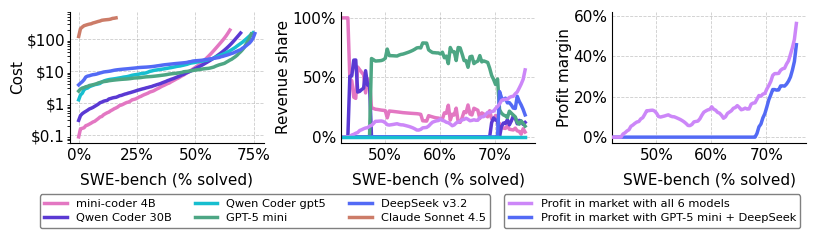

In [11]:
fig, axs = plt.subplots(1, 3, 
    figsize=(9.5, 1.7), 
    sharex=False
)

linewidth = 2.5
alpha = 1.0
palette = sns.color_palette()

model_names = {
    'minicoder4b': 'mini-coder 4B',
    'qwen3-coder-30b': 'Qwen Coder 30B',
    'qwen3-coder-480b': 'Qwen Coder gpt5',
    'gpt5mini': 'GPT-5 mini',
    'deepseek': 'DeepSeek v3.2',
    'sonnet': 'Claude Sonnet 4.5',
}

model2color = {
    'minicoder4b': palette[-4],
    'qwen3-coder-30b': (90/255, 57/255, 211/255),
    'qwen3-coder-480b': palette[-1],
    'gpt5mini': (77/255, 166/255, 132/255),
    'deepseek': (83/255, 106/255, 245/255),
    'sonnet': (204/255, 124/255, 104/255),
}
profitcolor = (204/255, 135/255, 248/255)

ax = axs[0]

for i in range(provider_prices_plot.shape[0]):
    ax.plot(
        performance_grid_plot,
        provider_prices_plot[i]*500,
        color=model2color[models[i]],
        linewidth=linewidth,
        zorder=6,
    )

ax.set_yscale('log')
# ax.set_x/lim(1e-3, 1)

ax = axs[1]
mycolors = [
    model2color[models[0]],
    model2color[models[1]],
    model2color[models[3]],
    model2color[models[4]],
    profitcolor,
]
for i in range(arbitrage_share.shape[0]):
    ax.plot(
        performance_grid,
        arbitrage_share[i],
        color=mycolors[i],
        linewidth=linewidth,
        alpha=alpha
    )
# plot qwen coder gpt5 at 0
ax.plot(
    performance_grid,
    np.zeros_like(performance_grid),
    color=model2color[models[2]],
    linewidth=linewidth,
    alpha=alpha
)

# plot market_price_plot

ax = axs[2]

ax.plot(
    performance_grid,
    profit_margin,
    linewidth=2.5,
    alpha=alpha,
    color=profitcolor,
    zorder=4,
    linestyle="-",
    label="Profit in market with all 6 models"
)
ax.plot(
    performance_grid,
    profit_margin2,
    linewidth=2.5,
    alpha=alpha,
    color=model2color[models[-2]],
    linestyle="-",
    label="Profit in market with GPT-5 mini + DeepSeek"
)


def format_ax(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)

    ax.grid(alpha=0.4, linewidth=0.6, linestyle="--", color="gray", zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(labelsize=11, direction="out", length=0, width=0.8)

for ax in axs:
    format_ax(ax)

axs[0].set_ylabel("Cost", fontsize=11, fontweight="normal", labelpad=1)
axs[0].set_xlabel("SWE-bench (% solved)", fontsize=11, fontweight="normal", labelpad=7)
axs[2].set_xlabel("SWE-bench (% solved)", fontsize=11, fontweight="normal", labelpad=7)
axs[2].set_ylabel("Profit margin", fontsize=11, fontweight="normal", labelpad=1)
axs[1].set_xlabel("SWE-bench (% solved)", fontsize=11, fontweight="normal", labelpad=7)
axs[1].set_ylabel("Revenue share", fontsize=11, fontweight="normal", labelpad=1)

format_ax = lambda x, p: f"${x:.0f}" if x >= 1 else f"${x:.1f}"
axs[0].yaxis.set_major_formatter(FuncFormatter(format_ax))
axs[0].xaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{x*100:.0f}%"))
axs[2].xaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{x*100:.0f}%"))
axs[2].yaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{x*100:.0f}%"))
axs[1].xaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{x*100:.0f}%"))
axs[1].yaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{x*100:.0f}%"))

# make legend with all the models
legend_elements = [
    Line2D([0], [0], color=model2color[models[i]], linewidth=linewidth, label=model_names[models[i]])
    for i in range(len(models))
]
axs[0].legend(
    handles=legend_elements,
    loc="best",
    fontsize=8.2,
    framealpha=1.0,
    ncol=3,
    edgecolor="gray",
    fancybox=True,
    frameon=True,
    labelspacing=0.4,
    bbox_to_anchor=(2.2, -0.35),
)
axs[2].legend(
    loc="best",
    fontsize=8.2,
    framealpha=1.0,
    bbox_to_anchor=(1., -0.35),
    edgecolor="gray",
    fancybox=True,
    frameon=True,
    labelspacing=0.4,
)
fig.subplots_adjust(wspace=0.4)
axs[2].set_yticks([0, 0.2, 0.4, 0.6])
axs[2].set_ylim(None, 0.62)
axs[1].set_xlim(0.42, None)
axs[2].set_xlim(0.42, None)


plt.savefig(f"plots/figs-many.pdf", bbox_inches="tight")

## Figure 8 - mini-coder

In [12]:
budget_grid = np.logspace(np.log10(1e-4), np.log10(0.5), 250)
models = ['minicoder4b', 'qwen3-coder-30b', 'gpt5mini']
providers_perf = load_pass_curves(results, models, budget_grid)
coder_gpt5 = providers_perf[:, [1, 2]]
mini_gpt5 = providers_perf[:, [0, 2]]

# provider prices...
performance_grid = jnp.linspace(0.4, providers_perf.mean(axis=0).max(), 100)
provider_prices = np.array([
    cost_for_pass(budget_grid, p, performance_grid)
    for p in providers_perf.mean(axis=0)
])
market_price = provider_prices.min(axis=0)

In [13]:
# we evaluate profit from 5% solve rate to frontier solve rate
max_perf = providers_perf.mean(axis=0).max()
performance_grid = jnp.linspace(0.05, max_perf, 100)

# grid of compute allocations
compute_first = np.r_[0, np.logspace(np.log10(0.01), np.log10(0.3), 100), budget_grid.max()]
compute_second = budget_grid.max() - compute_first
compute_allocation = np.stack([compute_first, compute_second], axis=-1)

In [14]:
# compute profit for each compute allocation, and select the best
mean_profits = threshold_to_profit_batch(
    budget_grid,
    coder_gpt5,
    compute_allocation,
    performance_grid
).mean(axis=-1)  # mean across the performance grid
allocation_coder = compute_allocation[np.argmax(mean_profits, axis=-1)]

# compute profit for each compute allocation, and select the best
mean_profits = threshold_to_profit_batch(
    budget_grid,
    mini_gpt5,
    compute_allocation,
    performance_grid
).mean(axis=-1)  # mean across the performance grid
allocation_mini = compute_allocation[np.argmax(mean_profits, axis=-1)]

print(f"Optimal budget allocation (coder 30B + gpt5): {allocation_coder}")
print(f"Optimal budget allocation (mini-coder 4B + gpt5): {allocation_mini}")

Optimal budget allocation (coder 30B + gpt5): [0.02443041 0.47556959]
Optimal budget allocation (mini-coder 4B + gpt5): [0.01034952 0.48965048]


In [15]:
cost_minicoder, _ = get_arbitrage_prices(budget_grid, mini_gpt5, allocation_mini, performance_grid)
cost_coder, _ = get_arbitrage_prices(budget_grid, coder_gpt5, allocation_coder, performance_grid)
cost_gpt5 = cost_for_pass(budget_grid, providers_perf.mean(axis=0)[2], performance_grid)

market_mini = np.minimum(cost_minicoder, cost_gpt5)
market_coder = np.minimum(cost_coder, cost_gpt5)

Grid search over the 3-provider market

In [16]:
max_budget = 1
computes = np.r_[0, np.logspace(np.log10(1e-3), np.log10(max_budget), 20)]
X1, X2, X3 = np.meshgrid(
    computes, computes, computes,
    indexing="ij"
)

points = np.stack((X1, X2, X3), axis=-1).reshape(-1, 3)

points = enforce_row_sum(points, max_budget)
points = np.unique(np.round(points, decimals=8), axis=0)

mask = is_monotonic_ignore_zeros(points)
points = points[mask]

In [17]:
arbitrage_cost_all, arbitrage_expend_all = prices_vmap(budget_grid, providers_perf, points, performance_grid)

Grid search over only Qwen Coder and GPT-5 mini

In [18]:
# do arbitrage over the first two models...
compute_first = np.r_[0, np.logspace(np.log10(0.01), np.log10(0.5), 100), budget_grid.max()]
compute_second = budget_grid.max() - compute_first
compute_allocation = np.stack([compute_first, compute_second], axis=-1)

arbitrage_cost_all2, arbitrage_expend_all2 = prices_vmap(budget_grid, providers_perf[:, [1, 2]], compute_allocation, performance_grid)

In [19]:
# all 3 models
idsmin = np.argmin(arbitrage_cost_all, axis=0)
arbitrage_expend = arbitrage_expend_all[idsmin, :, np.arange(idsmin.shape[0])]
arbitrage_cost = arbitrage_cost_all.min(axis=0)

# only qwen coder and gpt-5 mini
idsmin2 = np.argmin(arbitrage_cost_all2, axis=0)
arbitrage_expend2 = arbitrage_expend_all2[idsmin2, :, np.arange(idsmin2.shape[0])]
arbitrage_cost2 = arbitrage_cost_all2.min(axis=0)

Get the market share of both

In [20]:
def get_share(provider_prices, market_price, arbitrage_cost, arbitrage_expend):
    not_competitive = (provider_prices > market_price[None])
    provider_revenue = np.where(not_competitive, 0, provider_prices)

    arbitrage_better = (arbitrage_cost < market_price)
    arbitrage_revenue = np.where(arbitrage_better[None], arbitrage_expend.T, provider_revenue)

    arbitrage_share = arbitrage_revenue / arbitrage_revenue.sum(axis=0)
    return arbitrage_share

share3 = get_share(provider_prices, market_price, arbitrage_cost, arbitrage_expend)
share2 = get_share(provider_prices[[1, 2]], provider_prices[[1, 2]].min(axis=0), arbitrage_cost2, arbitrage_expend2)

In [21]:
before_minicoder = share2[0] # share of qwen coder in the two model market
after_minicoder = share3[1] # share of qwen coder in the market with all 3 models

# smooth
window = 3
before_minicoder = np.convolve(before_minicoder, np.ones(window)/window, mode='valid')
after_minicoder = np.convolve(after_minicoder, np.ones(window)/window, mode='valid')
performance_grid_conv = np.convolve(performance_grid, np.ones(window)/window, mode='valid')

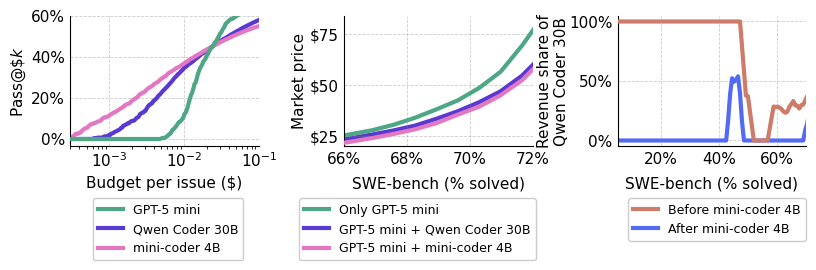

In [22]:
# 1x2 plot...
fig, axs = plt.subplots(
    1, 3, figsize=(9.5, 1.7)#, gridspec_kw={"width_ratios": [1.5, 2]}
)

palette = sns.color_palette()

linewidth = 3

mean_perf = providers_perf.mean(axis=0)
labels = [
    "mini-coder 4B",
    "Qwen Coder 30B",
    "GPT-5 mini",
]
colors = [
    palette[-4],
    model2color['qwen3-coder-30b'],
    model2color['gpt5mini'],
]
zorders = [2, 1, 3]
for i in range(mean_perf.shape[0]):
    axs[0].plot(
        budget_grid,
        mean_perf[i],
        label=labels[i],
        color=colors[i],
        linewidth=linewidth,
        zorder=zorders[i],
    )
axs[0].set_xlim(3e-4, 1e-1)

# axs[0].yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'${x:.0f}'))

axs[0].set_xscale("log")
axs[0].set_xlim(None, 1e-1)
axs[0].set_ylim(None, 0.6)

axs[1].plot(
    performance_grid,
    cost_gpt5,
    color=model2color['gpt5mini'],
    alpha=1.0,
    linewidth=linewidth,
    zorder=2,
)
axs[1].plot(
    performance_grid,
    market_coder,
    label="Open market: Qwen Coder 30B + 480B",
    color=model2color['qwen3-coder-30b'],
    alpha=1.0,
    linewidth=linewidth,
    zorder=0,
    linestyle="-",
)
axs[1].plot(
    performance_grid,
    market_mini,
    label="Gatekeeped market: mini-coder 4B + 480B",
    color=palette[-4],
    alpha=1.0,
    linewidth=linewidth,
    zorder=3.5,
    linestyle="-",
)

axs[1].set_xlim(0.66, 0.72)
axs[1].set_ylim(20/500, cost_gpt5.max())

ax = axs[2]
ax.plot(
    performance_grid_conv,
    before_minicoder,
    color=model2color['sonnet'],
    linewidth=linewidth,
    zorder=3.5,
    linestyle="-",
)
ax.plot(
    performance_grid_conv,
    after_minicoder,
    color=model2color['deepseek'],
    linewidth=linewidth,
    zorder=2,
)
ax.set_xlim(0.05, 0.7)


def format_ax(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)

    ax.grid(alpha=0.4, linewidth=0.6, linestyle="--", color="gray", zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(labelsize=11, direction="out", length=0, width=0.8)


for ax in axs:
    format_ax(ax)

axs[0].set_ylabel("Pass@\$$k$", fontsize=11, fontweight="normal", labelpad=2)
axs[0].set_xlabel("Budget per issue ($)", fontsize=11, fontweight="normal", labelpad=4)
axs[1].set_ylabel("Market price", fontsize=11, fontweight="normal", labelpad=2)
axs[1].set_xlabel("SWE-bench (% solved)", fontsize=11, fontweight="normal", labelpad=7)
axs[2].set_xlabel("SWE-bench (% solved)", fontsize=11, fontweight="normal", labelpad=7)
axs[2].set_ylabel("Revenue share of\nQwen Coder 30B", fontsize=11, fontweight="normal", labelpad=0)

axs[0].yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x*100:.0f}%'))
axs[1].xaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{x * 100:.0f}%"))
axs[1].yaxis.set_major_formatter(FuncFormatter(lambda x, p: f"${x*500:.0f}"))
axs[2].xaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{x * 100:.0f}%"))
axs[2].yaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{x * 100:.0f}%"))

# legend for the first plot... three lin2d, one for each model...
axs[0].legend(
    loc="best",
    ncol=1,
    fontsize=9,
    framealpha=1.0,
    # place below the plot...
    bbox_to_anchor=(0.95, -0.35),
)

legend_elements = [
    Line2D([0], [0], color=model2color['gpt5mini'], linewidth=linewidth, label='GPT-5 mini'),
    Line2D([0], [0], color=model2color['qwen3-coder-30b'], linewidth=linewidth, label='Qwen Coder 30B'),
    Line2D([0], [0], color=palette[-4], linewidth=linewidth, label='mini-coder 4B'),
]
axs[0].legend(
    handles=legend_elements,
    loc="best",
    ncol=1,
    fontsize=9,
    framealpha=1.0,
    bbox_to_anchor=(0.95, -0.35),
)
# for second plot...
legend_elements = [
    Line2D([0], [0], color=model2color['gpt5mini'], linewidth=linewidth, label='Only GPT-5 mini'),
    Line2D([0], [0], color=model2color['qwen3-coder-30b'], linewidth=linewidth, label='GPT-5 mini + Qwen Coder 30B'),
    Line2D([0], [0], color=palette[-4], linewidth=linewidth, label='GPT-5 mini + mini-coder 4B'),
]
axs[1].legend(
    handles=legend_elements,
    loc="best",
    ncol=1,
    fontsize=9,
    framealpha=1.0,
    bbox_to_anchor=(1.05, -0.35),
)

legend_elements = [
    Line2D([0], [0], color=model2color['sonnet'], linewidth=linewidth, label='Before mini-coder 4B'),
    Line2D([0], [0], color=model2color['deepseek'], linewidth=linewidth, label='After mini-coder 4B'),
]
axs[2].legend(
    handles=legend_elements,
    loc="best",
    ncol=1,
    fontsize=9,
    framealpha=1.0,
    bbox_to_anchor=(1.03, -0.35),
)

fig.subplots_adjust(wspace=0.45)
plt.savefig(f"plots/fig4-plot.pdf", bbox_inches="tight")